# SME end-to-end: symbolic derivation → solver tags → numerical solve

This notebook walks the full pipeline for the **tag-driven** Shallow Moment
Equations (`SMEModelTagged`):

1. Build the model and inspect its symbolic derivation.
2. Inspect the `solver_tag` decomposition of each projected equation.
3. Read off the numerical operators (`flux`, `source`,
   `nonconservative_matrix`, `hydrostatic_pressure`) — all extracted from
   the tagged equations via `collect_solver_tag`.
4. Compile to numpy and run a short simulation with `HyperbolicSolver`.
5. Compare with the hand-coded `SMEModel` reference — parity should be
   bit-identical.

## Imports

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from zoomy_core.model.models.sme_model import SMEModel, SMEModelTagged
from zoomy_core.mesh import BaseMesh, ensure_lsq_mesh
from zoomy_core.kernel import Kernel
from zoomy_core.transformation.to_numpy import NumpyRuntimeModel
from zoomy_core.fvm.solver_numpy import HyperbolicSolver
import zoomy_core.fvm.timestepping as ts
import zoomy_core.model.boundary_conditions as BC
import zoomy_core.model.initial_conditions as IC

## Build the model and inspect its derivation

`SMEModelTagged` inherits the full `SMEModel` derivation chain
(FullINS → hydrostatic → depth-integrate → kinematic BCs →
stress-free surface → zero atmospheric pressure → Newtonian material).

In [2]:
LEVEL = 1
model = SMEModelTagged(level=LEVEL)
print("n_variables:", model.n_variables)
print("variables:  ", model.variables)

n_variables: 4
variables:   Zstruct(b=b, h=h, q2=q2, q3=q3)


The symbolic derivation is recoverable via `describe()`:

In [3]:
print(model.describe(derivation="markdown"))

**SMEModelTagged** (continuity, x_momentum) — solver-ready

**Derivation path:**

#### SMEModel

**continuity:** $\frac{\partial}{\partial t} h{\left(t,x \right)} + \frac{\partial}{\partial x} \int\limits_{b{\left(t,x \right)}}^{b{\left(t,x \right)} + h{\left(t,x \right)}} u{\left(t,x,z \right)}\, dz = 0$

**x_momentum:** $- u{\left(t,x,b{\left(t,x \right)} + h{\left(t,x \right)} \right)} \frac{\partial}{\partial t} b{\left(t,x \right)} - u{\left(t,x,b{\left(t,x \right)} + h{\left(t,x \right)} \right)} \frac{\partial}{\partial t} h{\left(t,x \right)} + u{\left(t,x,b{\left(t,x \right)} \right)} \frac{\partial}{\partial t} b{\left(t,x \right)} + \frac{\partial}{\partial t} \int\limits_{b{\left(t,x \right)}}^{b{\left(t,x \right)} + h{\left(t,x \right)}} u{\left(t,x,z \right)}\, dz + u{\left(t,x,b{\left(t,x \right)} + h{\left(t,x \right)} \right)} \frac{\partial}{\partial t} b{\left(t,x \right)} + u{\left(t,x,b{\left(t,x \right)} + h{\left(t,x \right)} \right)} \frac{\partial}{\partial t} 

## Inspect the solver tags on each post-projection scalar equation

`_operator_system.equations` holds the scalar equations
(one per output row). Each equation carries five canonical solver tags
whose sum equals the full LHS (the `untagged_remainder` invariant).

In [4]:
for name, eq in model._operator_system.equations.items():
    print(f"\n=== {name} ===")
    print("  expr (LHS = 0):", eq.expr)
    for tag, piece in eq.solver_tags.items():
        print(f"  solver_tag[{tag:22s}] = {piece}")
    print("  untagged remainder:", eq.untagged_remainder())


=== continuity ===
  expr (LHS = 0): Derivative(0, x) + Derivative(h, t) + Derivative(q2, x)
  solver_tag[time_derivative       ] = Derivative(h, t)
  solver_tag[flux                  ] = Derivative(q2, x)
  solver_tag[hydrostatic_pressure  ] = Derivative(0, x)
  solver_tag[nonconservative_flux  ] = 0
  solver_tag[source                ] = 0
  untagged remainder: 0

=== x_momentum_0 ===
  expr (LHS = 0): -ex*g*h + ez*g*h*Derivative(b, x) + Derivative(q2, t) + Derivative(ez*g*h**2/2, x) + Derivative(q2**2/h + q3**2/(3*h), x) - (-q2/h - q3/h)/lamda
  solver_tag[time_derivative       ] = Derivative(q2, t)
  solver_tag[flux                  ] = Derivative(q2**2/h + q3**2/(3*h), x)
  solver_tag[hydrostatic_pressure  ] = Derivative(ez*g*h**2/2, x)
  solver_tag[nonconservative_flux  ] = ez*g*h*Derivative(b, x)
  solver_tag[source                ] = -ex*g*h - (-q2/h - q3/h)/lamda
  untagged remainder: 0

=== x_momentum_1 ===
  expr (LHS = 0): Derivative(0, x) + Derivative(q3, t) + Derivative(

## Numerical operators (read off the tags)

Each body below is a one-liner over `collect_solver_tag`:
```python
def flux(self):              return ZArray(self._collect("flux",     shape_dirs=1))
def source(self):            return -ZArray(self._collect("source",  shape_dirs=0))
def nonconservative_matrix(self):  return ZArray(self._collect("nonconservative_flux", shape_dirs=1))
def hydrostatic_pressure(self):    return ZArray(self._collect("hydrostatic_pressure", shape_dirs=1))
```

In [5]:
F  = model.flux()
S  = model.source()
NC = model.nonconservative_matrix()
Hp = model.hydrostatic_pressure()
print("flux                 :", sp.Matrix(F).T)
print("source               :", sp.Matrix(list(S)).T)
print("hydrostatic_pressure :", sp.Matrix(Hp).T)
print("nonconservative_matrix (rank-3) shape:", NC.shape)

flux                 : Matrix([[0, q2, q2**2/h + q3**2/(3*h), 2*q2*q3/h]])
source               : Matrix([[0, 0, ex*g*h + (-q2/h - q3/h)/lamda, 3*(-q2/h - q3/h)/lamda - 12*nu*q3/h**2]])
hydrostatic_pressure : Matrix([[0, 0, ez*g*h**2/2, 0]])
nonconservative_matrix (rank-3) shape: (4, 4, 1)


## Parity with hand-coded SMEModel (the reference)

In [6]:
ref = SMEModel(level=LEVEL)

def _matrix_delta(a, b):
    return sp.simplify(sp.Matrix(a) - sp.Matrix(b))

print("flux     diff:", _matrix_delta(ref.flux(),                   F))
print("source   diff:", _matrix_delta(list(ref.source()),           list(S)))
print("hydro    diff:", _matrix_delta(ref.hydrostatic_pressure(),   Hp))
# NC rank-3: check elementwise
nc_diffs = [sp.simplify(ref.nonconservative_matrix()[i, j, k] - NC[i, j, k])
            for i in range(model.n_variables)
            for j in range(model.n_variables)
            for k in range(model.dimension)]
print("NC max diff:", max((str(d) for d in nc_diffs if d != 0), default="0"))

flux     diff: Matrix([[0], [0], [0], [0]])
source   diff: Matrix([[0], [0], [0], [0]])
hydro    diff: Matrix([[0], [0], [0], [0]])
NC max diff: 0


## Compile and run

Short 1D test: Gaussian bump in water height, periodic-length domain, 40
cells, 0.05 s.  Both reference and tagged models are compiled and solved
— the states at t = 0.05 s should agree to machine precision.

In [7]:
def _run(cls):
    np.random.seed(1)
    m = cls(level=LEVEL)
    m.boundary_conditions = BC.BoundaryConditions(
        boundary_conditions_list=[BC.Extrapolation(tag=t) for t in ("left", "right")])
    m.initial_conditions = IC.UserFunction(
        function=lambda X: np.array(
            [0.0, 0.5 + 0.1 * np.exp(-((X[0] - 5) ** 2) / 0.5)] + [0.0] * (LEVEL + 1)
        )
    )
    mesh = BaseMesh.create_1d((0, 10), 40)
    Q, _ = HyperbolicSolver(
        time_end=0.05, compute_dt=ts.adaptive(CFL=0.3)
    ).solve(mesh, m, write_output=False)
    return mesh, Q

mesh_ref, Q_ref = _run(SMEModel)
mesh_tag, Q_tag = _run(SMEModelTagged)
print(f"max |ref - tag| over all fields/cells: "
      f"{np.max(np.abs(Q_ref[:, :40] - Q_tag[:, :40])):.2e}")

2026-04-18 20:48:14.059 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:636 - Finished simulation with in 0.020 seconds


2026-04-18 20:48:14.831 | INFO     | zoomy_core.fvm.solver_numpy:run_simulation:636 - Finished simulation with in 0.019 seconds


max |ref - tag| over all fields/cells: 0.00e+00


## Plot h and hu_0 side-by-side

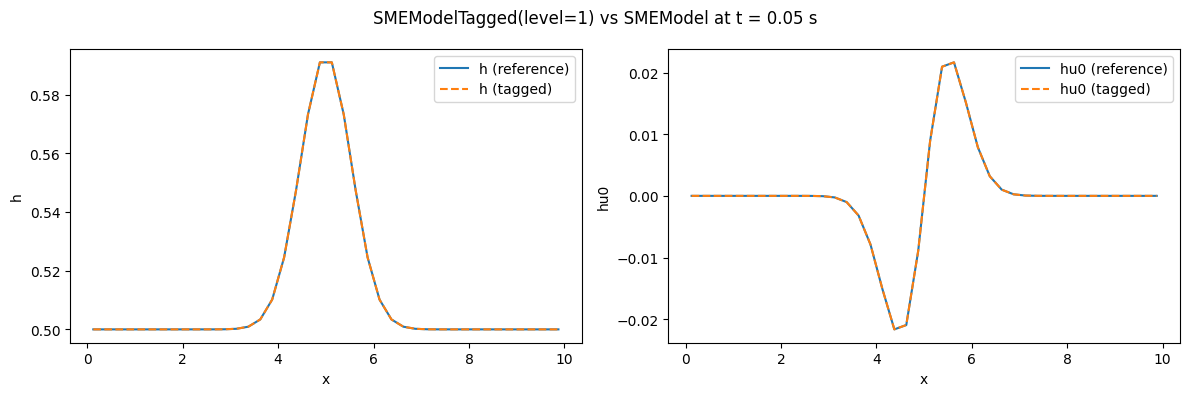

In [8]:
xc = ensure_lsq_mesh(mesh_ref).cell_centers[0, :40]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(xc, Q_ref[1, :40], label="h (reference)")
axes[0].plot(xc, Q_tag[1, :40], "--", label="h (tagged)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("h"); axes[0].legend()
axes[1].plot(xc, Q_ref[2, :40], label="hu0 (reference)")
axes[1].plot(xc, Q_tag[2, :40], "--", label="hu0 (tagged)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("hu0"); axes[1].legend()
fig.suptitle(f"SMEModelTagged(level={LEVEL}) vs SMEModel at t = 0.05 s")
fig.tight_layout()
plt.show()